# Recap of Week 4 Topics


In our last lesson, we moved beyond static circuits and explored **Parameterized Circuits**. By using `Parameter` objects, we learned how to create a single circuit "template" where gate angles remain flexible. This is the backbone of **variational algorithms**, as it allows a classical optimizer to find the best possible quantum state for our problem without us having to redefine the circuit from scratch for every minor adjustment.

To handle these circuits efficiently, we introduced Qiskit Primitives: **Sampler** and **Estimator**. While the Sampler gives us bitstring distributions, the Estimator is our heavy lifter for **variational algorithms** - it calculates the expectation value of an operator (like energy) for our parameterized state, making the feedback loop between the quantum processor and the classical optimizer seamless and efficient.

---

# Variational Quantum Eigensolver (VQE)

[reference: https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/vqe]

The Variational Quantum Eigensolver (VQE) is a hybrid algorithm designed to find the ground state of a system. In physics and chemistry, everything wants to be in its lowest energy state. If we can find that state, we can understand how molecules bond, how materials conduct electricity, or even how to optimize complex logistics routes.

Given a system described by a mathematical operator called a Hamiltonian ($H$), VQE finds the lowest possible eigenvalue (the ground state energy) and its corresponding eigenvector (the quantum state).

Because finding the ground state is computationally expensive for classical computers as systems get larger, we use a quantum circuit to prepare candidate states and a classical optimizer to nudge the parameters until we find the minimum.

---

# Toy VQE

We will start by applying VQE to a very simple case, to see how it works. We will compute the minimum eigenvalue of Pauli Z matrix with VQE. 

$$ H = Z $$

We already know the solution to this problem. We have seen previously that when we measure in the Z basis (the computational basis), our state collapses to one of its two eigenstates: $|0\rangle$ or $|1\rangle$ with corresponding eigenvalues $+1$ and $-1$ respectively.

We now define the operator of interest and view it in matrix form.

In [19]:
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp("Z")
hamiltonian.to_matrix()

array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

It is easy to obtain the eigenvalues classically, so we can check our work. This might become difficult as we scale toward utility. Here we use numpy.

In [103]:
import numpy as np

eigenstates = np.linalg.eigh(hamiltonian.to_matrix())
print("Eigenvalues:\n", eigenstates.eigenvalues)
print("Eigenvectors:\n", eigenstates.eigenvectors)

Eigenvalues:
 [-1.  1.]
Eigenvectors:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


As expected, we see the eigenvectors and eigenvalues of the Z operator.

---

## Solving with VQE

Remember that when we initialise a `QuantumCircuit` the states of each qubit start in the $|0\rangle$ state. The minimum eigenstate (ie the eigenvector with the lowest corresponding eigenvalue) of the Z operator is the $|1\rangle$ state. Therefore, when we design our parameterized circuit we should be careful to choose our rotation(s) wisely...

### Exercise

To get from the $|0\rangle$ state to the $|1\rangle$ state we only need to rotate our qubit in one dimension. What rotation gate should we use? There is only one *wrong* answer.

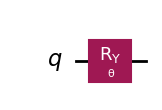

In [111]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

angle = Parameter("θ")

qc = QuantumCircuit(1)
qc.ry(angle, qubit=0)
qc.draw("mpl")

In [112]:
from qiskit.primitives import BackendEstimatorV2
from qiskit_aer import AerSimulator

simulator = AerSimulator()
estimator = BackendEstimatorV2(backend=simulator)

angles = [0, np.pi/2, np.pi]
pub = (
    qc,             
    hamiltonian,    
    angles          
    )                

job = estimator.run(pubs=[pub])
print(f"Estimator Result: {job.result()[0].data.evs}")

Estimator Result: [ 1.          0.01513672 -1.        ]


In [113]:
from qiskit.quantum_info import Statevector

qc_bound = qc.assign_parameters({angle: np.pi}, inplace=False)
statevector = Statevector.from_instruction(qc_bound)
print(statevector.data)

[6.123234e-17+0.j 1.000000e+00+0.j]


In the cell above we manually chose our angles to bind to the circuit because we knew the solution *a priori*. 

The idea of VQE (and variational algorithms more generally) is that a classical optimizer will find the angle for us.

To do this we need to set up a loss function.

# Loss function

The loss function will essentially wrap around the `estimator.run(pub)` line where we allow the parameter values (angles) of the PUB to a variable of the function, and the function itself returns the cost ie the expectation value returned by the estimator.

In [114]:
loss = []
def cost(angle_value: float) -> float:
    """
    Cost function for VQE. 
    
    Args:
        angle_value (float): The value of the parameter to evaluate the 
        cost at.

    Returns:
        float: The expectation value of the Hamiltonian with respect to
        the quantum circuit parameterized by the given angle value.

    Explanation: 
        This function takes a parameter value (angle_value) 
        and evaluates the expectation value of the Hamiltonian with 
        respect to the quantum circuit parameterized by that angle. The 
        result is appended to the loss list and printed out. This cost 
        function is what we will minimize in the VQE algorithm to find 
        the optimal parameters that yield the lowest energy (expectation 
        value) for the given Hamiltonian.
    """

    pub = (qc, hamiltonian, [angle_value])
    result = estimator.run(pubs=[pub]).result()
    expval = result[0].data.evs[0]
    loss.append(expval)
    print(expval)
    return expval

We will use scipy's minimize function to `minimize` our loss function. `minimize` requires an objective function to minimize and an initial 'guess' `x0`.

In [115]:
from scipy.optimize import minimize

min_result = minimize(
    fun=cost, 
    x0=[0],                                 # initial guess for the parameter (angle) to start the optimization
    method="COBYLA",                        # a gradient-free optimization method
    options={"maxiter": 30, "disp": True})  # limits the number of iterations to 20 and displays optimization progress

1.0
0.53857421875
-0.39892578125
-0.67041015625
0.96142578125
-0.9892578125
-0.40625
-0.93359375
-0.92529296875
-0.9990234375
-0.9970703125
-0.994140625
-0.99853515625
-0.998046875
-0.99951171875
-1.0
-1.0
-0.99951171875
-1.0
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 19   Least value of F = -1.0
The corresponding X is: [3.12]



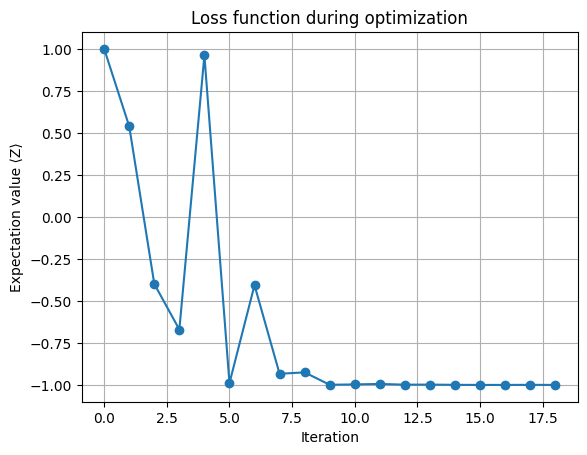

In [116]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Expectation value ⟨Z⟩")
plt.title("Loss function during optimization")
plt.grid(True)
plt.show()

In [117]:
best_angle = min_result.x

qc_bound = qc.assign_parameters({angle: best_angle}, inplace=False)
statevector = Statevector.from_instruction(qc_bound)
print(statevector.data)

[0.01079612+0.j 0.99994172+0.j]


As we can see, our algorithm successfully changed the angle of rotation of our parameterized circuit such that it found the ground state of our (very simple) Hamiltonian.

Let's review the steps: 

1. We setup our **Hamiltonian**, which was just the Z operator. 
2. We built a **parameterized circuit** where we wisely chose not to rotate about the Z axis. 
3. We built a **loss function** which used the **estimator primitive** to find the **expectation value** of our Hamiltonian.
4. We fed our loss function into a **classical minimizer** along with some initial conditions.

The first two steps of this algorithm is what deminds some clever choices on our part. 

Because we chose a very simple problem/Hamiltonian this didn't require much thinking. However in real use cases building the problem Hamiltonian is much less trivial and often the most challenging step. Typically, it requires mapping some kind of optimization/logistics problem to qubit representation a quantum computer can 'understand'. In this case the resulting state at the end of the algorithm would represent a (hopefully accurate) solution to the problem. For example, the bitstring representation of the most populated basis state could represent the best route to take in a [travelling salesman problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem). 

Because we knew that we needed to get from the $|0\rangle$ state to the $|1\rangle$ state, we knew that it would be a bad to idea to rotate about the Z-axis in our parameterized circuit, as that wouldn't evolve our state at all. We had some knowledge about the system we were tring to minimize (in the sense that we actually knew what the solution should be), and carefully designed our circuit accordingly - this is called an **ansatz**, the German word for "approach". Naturally, we typically don't know the solution to our problem beforehand, but if we can make some clever insight into our system then we might be able to make a good **ansatz circuit** that will find a solution more efficiently.

---

# An ever so slightly more complex problem

To demonstrate a scenario where we need to build a more involved Hamiltonian and ansatz, we will solve a slightly more complicated problem. 

## The Green Energy Grid Problem

We are managing two power substations: **Augsburg** (qubit 0) and **Berlin** (qubit 1). Each can draw power from **Solar** (which will correspond to that qubit being in state $|0\rangle$) or **Coal** (which will correspond to that qubit being in state $|1\rangle$).

Our Constraints:

1. Augsburg Bias ($+0.8 Z_0$): Augsburg has high coal taxes. It is much cheaper to stay on solar.
2. Berlin Bias ($-0.5 Z_1$): Berlin has a coal subsidy. It is cheaper to use coal.
3. Grid Stability ($+1.0 Z_0 Z_1$): If both nodes use the same source at the same time, the grid overloads. They are rewarded for being different (one Coal, one Solar).

#### **1. The Hamiltonian** $$H = 0.8 Z_0 - 0.5 Z_1 + 1.0 Z_0 Z_1$$

In [163]:
h_list = [
    ("ZI", 0.8),   # Bias on Node 0
    ("IZ", -0.5),  # Bias on Node 1
    ("ZZ", 1.0),   # Stability Penalty
]

problem = SparsePauliOp.from_list(h_list)
print(f"Power Grid Hamiltonian:\n{problem.to_matrix()}")

Power Grid Hamiltonian:
[[ 1.3+0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0.3+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -2.3+0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0.7+0.j]]


In [165]:
eigenstates = np.linalg.eigh(problem.to_matrix())
print("Eigenvalues:\n", eigenstates.eigenvalues)
print("Ground State Energy:", min(eigenstates.eigenvalues))

Eigenvalues:
 [-2.3  0.3  0.7  1.3]
Ground State Energy: -2.3


#### **2. The Ansatz**

Now we add more rotations and entanglement between the qubits. This enables to search the full Hilbert space of possible solutions.

The $CX$ gate is the only way the circuit can "know" that the two nodes shouldn't draw from the same source, capturing the $ZZ$ Correlation. 

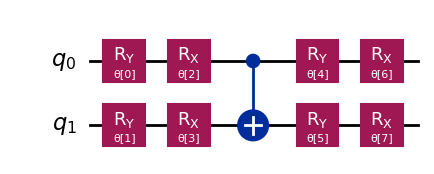

In [166]:
from qiskit.circuit import ParameterVector

params = ParameterVector("θ", 8)

ansatz = QuantumCircuit(2)

ansatz.ry(params[0], 0)
ansatz.ry(params[1], 1)
ansatz.rx(params[2], 0)
ansatz.rx(params[3], 1)

ansatz.cx(0, 1)

ansatz.ry(params[4], 0)
ansatz.ry(params[5], 1)
ansatz.rx(params[6], 0)
ansatz.rx(params[7], 1)

ansatz.draw("mpl")

#### **3. The Loss Function**

In [167]:
grid_loss = []
def grid_cost(params: list[float]) -> float:

    pub = (ansatz, problem, params)
    result = estimator.run(pubs=[pub]).result()
    expval = result[0].data.evs.item()
    grid_loss.append(expval)
    print(expval)
    return expval

In [ ]:
grid_min_result = minimize(
    fun=grid_cost, 
    x0=[0]*8,                                   # initial guess for the parameter (angle) to start the optimization
    method="COBYLA",                            # a gradient-free optimization method
    options={"maxiter": 100, "disp": True})     # limits the number of iterations to 100 and displays optimization progress

1.3
1.153076171875
0.500830078125
0.54072265625
0.18354492187500002
0.43964843750000004
-0.96611328125
-0.8998046875
-1.2197265625
-0.914306640625
-0.703125
-1.851318359375
-2.204296875
-2.07353515625
-2.0025390625
-1.45693359375
-1.83046875
-1.886669921875
-1.98291015625
-0.787158203125
-1.899658203125
-1.9142578125
-2.177197265625
-2.180859375
-2.225244140625
-2.241259765625
-2.262548828125
-2.24814453125
-2.2708984375
-2.25908203125
-2.264453125
-2.27607421875
-2.277099609375
-2.283837890625
-2.24140625
-2.287841796875
-2.2853515625
-2.285107421875
-2.286474609375
-2.27783203125
-2.281201171875
-2.283837890625
-2.28193359375
-2.2767578125
-2.287255859375
-2.2818359375
-2.28896484375
-2.2888671875
-2.28427734375
-2.281201171875
-2.286767578125
-2.284814453125
-2.286083984375
-2.282080078125
-2.28837890625
-2.284814453125
-2.2888671875
-2.28857421875
-2.289697265625
-2.288623046875
-2.28740234375
-2.289111328125
-2.284228515625
-2.284423828125
-2.279443359375
-2.287060546875
-2.287548

### **4. Post Processing**

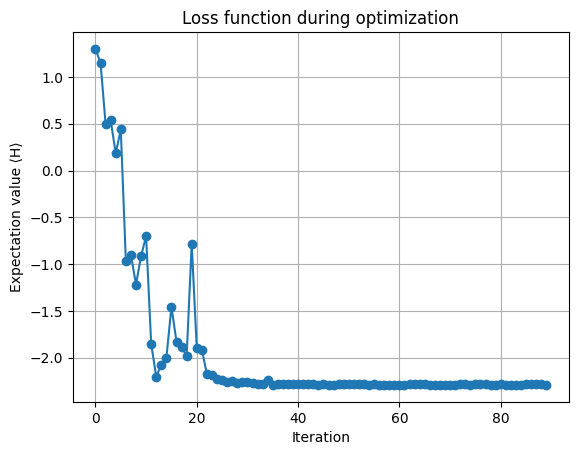

In [169]:
plt.figure()
plt.plot(grid_loss, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Expectation value ⟨H⟩")
plt.title("Loss function during optimization")
plt.grid(True)
plt.show()

In [170]:
best_angles = grid_min_result.x

ansatz_bound = ansatz.assign_parameters({params: best_angles}, inplace=False)
statevector = Statevector.from_instruction(ansatz_bound)
print(statevector.data)

[0.00403205-0.03904895j 0.01679448-0.00648572j 0.85268317-0.5184512j
 0.04529787+0.01492218j]


Sampled Results (Bitstrings): {'10': 1021, '01': 1, '00': 1, '11': 1}


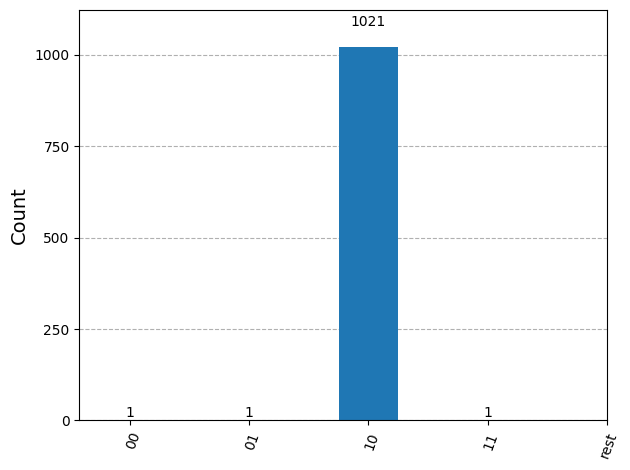

In [177]:
from qiskit.primitives import BackendSamplerV2
from qiskit.visualization import plot_histogram

sampler = BackendSamplerV2(backend=simulator)

ansatz_bound.measure_all()
job = sampler.run([ansatz_bound], shots=1024)
result = job.result()

# Get the counts for the first (and only) circuit
# result[0].data contains the classical register (usually named 'meas')
counts = result[0].data.meas.get_counts()

print("Sampled Results (Bitstrings):", counts)

plot_histogram(counts, number_to_keep=4)

So our algorithm has found with some certainty that Augsburg should draw from Coal, and Berlin should draw from Solar...? No, the other way round.

A little quirk of of Qiskit is that it uses 'little-endian' notation. Bitstrings are read from right to left, so the rightmost bit is Qubit 0 and the leftmost is your highest-indexed qubit.

So for our problem Qubit 0 (Augsburg) is in state $|0\rangle$ (Solar) and Qubit 1 (Berlin) is in state $|1\rangle$.